#### Import modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
text_data=pd.read_csv('../../data/text/raw_analyst_ratings.csv')

In [3]:
text_data.tail(10)

,Unnamed: 0,headline,url,publisher,date,stock
1407318,1413839,"Earnings Scheduled For August 22, 2012",https://www.benzinga.com/news/earnings/12/08/2...,Monica Gerson,2012-08-22 00:00:00,ZX
1407319,1413840,5 Auto Parts Stocks With The Highest Operating...,https://www.benzinga.com/trading-ideas/12/07/2...,Lisa Levin,2012-07-30 00:00:00,ZX
1407320,1413841,China Zenix Announces Open Market Stock Purcha...,https://www.benzinga.com/news/11/12/2233145/ch...,Eddie Staley,2011-12-30 00:00:00,ZX
1407321,1413842,China Zenix Auto International Awarded Wheel S...,https://www.benzinga.com/news/11/11/2153607/ch...,Allie Wickman,2011-11-28 00:00:00,ZX
1407322,1413843,China Zenix Auto International Selected as Exc...,https://www.benzinga.com/news/11/11/2142369/ch...,Eddie Staley,2011-11-21 00:00:00,ZX
1407323,1413844,Top Narrow Based Indexes For August 29,https://www.benzinga.com/news/11/08/1888782/to...,Monica Gerson,2011-08-29 00:00:00,ZX
1407324,1413845,Recap: Wednesday's Top Percentage Gainers and ...,https://www.benzinga.com/news/earnings/11/06/1...,Benjamin Lee,2011-06-22 00:00:00,ZX
1407325,1413846,UPDATE: Oppenheimer Color on China Zenix Auto ...,https://www.benzinga.com/analyst-ratings/analy...,BenzingaStaffL,2011-06-21 00:00:00,ZX
1407326,1413847,Oppenheimer Initiates China Zenix At Outperfor...,https://www.benzinga.com/analyst-ratings/price...,Joe Young,2011-06-21 00:00:00,ZX
1407327,1413848,China Zenix Auto International Opens For Tradi...,https://www.benzinga.com/news/ipos/11/05/10789...,Allie Wickman,2011-05-12 00:00:00,ZX


In [4]:
text_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


#### Date Time conversion

In [5]:
text_data['date_cleaned'] = text_data['date'].str.slice(0, 19)

text_data['date'] = pd.to_datetime(text_data['date_cleaned'], errors='coerce')

In [6]:
text_data['date'] = text_data['date'].dt.tz_localize('UTC').dt.tz_convert('US/Eastern')


text_data['publication_date'] = text_data['date'].dt.normalize()
text_data['hour'] = text_data['date'].dt.hour
text_data['day_of_week'] = text_data['date'].dt.day_name()

text_data.drop(columns=['date_cleaned'], inplace=True)

In [7]:
text_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 9 columns):
 #   Column            Non-Null Count    Dtype                     
---  ------            --------------    -----                     
 0   Unnamed: 0        1407328 non-null  int64                     
 1   headline          1407328 non-null  str                       
 2   url               1407328 non-null  str                       
 3   publisher         1407328 non-null  str                       
 4   date              1407328 non-null  datetime64[us, US/Eastern]
 5   stock             1407328 non-null  str                       
 6   publication_date  1407328 non-null  datetime64[us, US/Eastern]
 7   hour              1407328 non-null  int32                     
 8   day_of_week       1407328 non-null  str                       
dtypes: datetime64[us, US/Eastern](2), int32(1), int64(1), str(5)
memory usage: 91.3 MB


In [8]:

print(text_data.info())


<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 9 columns):
 #   Column            Non-Null Count    Dtype                     
---  ------            --------------    -----                     
 0   Unnamed: 0        1407328 non-null  int64                     
 1   headline          1407328 non-null  str                       
 2   url               1407328 non-null  str                       
 3   publisher         1407328 non-null  str                       
 4   date              1407328 non-null  datetime64[us, US/Eastern]
 5   stock             1407328 non-null  str                       
 6   publication_date  1407328 non-null  datetime64[us, US/Eastern]
 7   hour              1407328 non-null  int32                     
 8   day_of_week       1407328 non-null  str                       
dtypes: datetime64[us, US/Eastern](2), int32(1), int64(1), str(5)
memory usage: 91.3 MB
None


### Descriptive statistics
The following lines of codes compute descriptive statistics such as:
* Counting the headline length and plotting the distribution
* Counting the number of articles per publisher and identify the active ones
* Analyzing publication trend over time.

In [9]:
text_data['headline_len']=text_data['headline'].apply(len)
text_data['headline_len'].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64

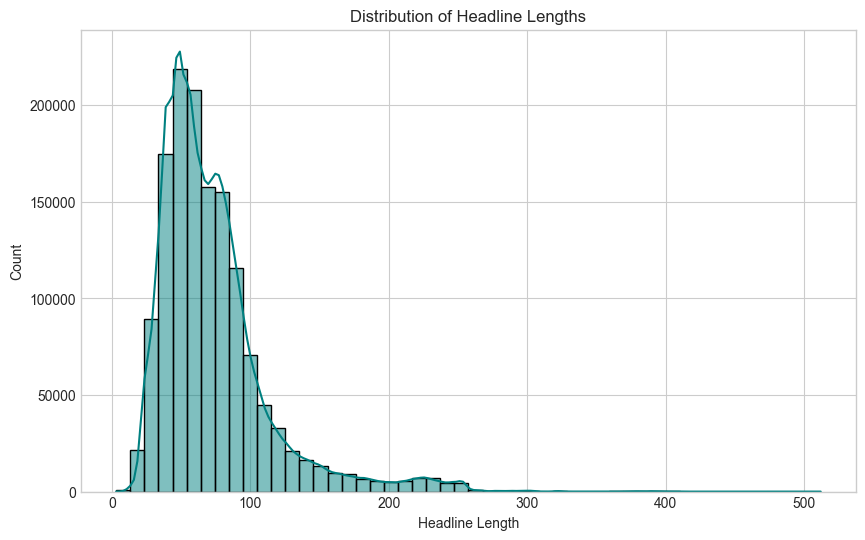

In [32]:
plt.figure(figsize=(10, 6))
sns.histplot(text_data['headline_len'], bins=50, kde=True, color='teal')
plt.title('Distribution of Headline Lengths')
plt.xlabel('Headline Length')
plt.show()

In [35]:
print(text_data['headline_len'].describe())

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64


In [37]:
text_data.groupby('publisher')['headline'].count().sort_values(ascending=False)

publisher
Paul Quintaro             228373
Lisa Levin                186979
Benzinga Newsdesk         150484
Charles Gross              96732
Monica Gerson              82380
                           ...  
MyConstant Chris Roper         1
milesyoung                     1
Nat                            1
mjintertrader                  1
Adam Weiner                    1
Name: headline, Length: 1034, dtype: int64

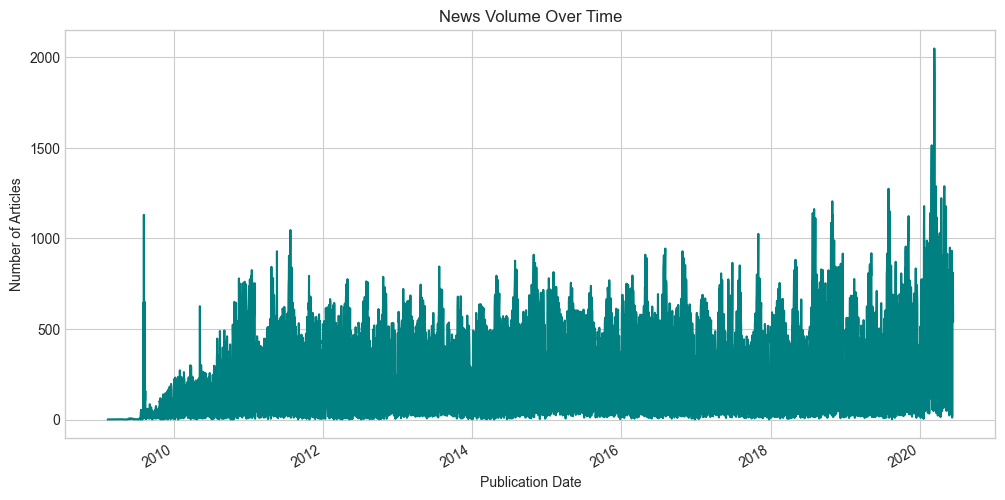

In [33]:
daily_news = text_data.groupby(text_data['publication_date']).size()

# Plot the timeline
plt.figure(figsize=(12, 6))
daily_news.plot(color='teal')
plt.title('News Volume Over Time')
plt.ylabel('Number of Articles')
plt.xlabel('Publication Date')
plt.show()

### Descriptive Statistics summary and interpretation
#### 1. Headline Length count and interpretation
Descriptive analysis of the 1,407,328 headlines length reveals a right-skewed distribution ($Mean=73 > Median=64$). The majority of news content (50%) adheres to a strict professional standard of 47–87 characters, ensuring compatibility with financial tickers. The presence of a 512-character maximum suggests that the dataset includes some long-form summaries, while the 3-character minimum indicates the presence of brief ticker-based alerts.

#### 2. Number of articles per Publisher
The top 5 publishers alone account for approximately 744,948 articles, which is over 53% of the entire 1.4 million record dataset. This indicates a long-tail distribution where a few contributors drive the majority of the news volume. 
The most active publishers are:

| Publisher | Article Count |
| :--- | :--- |
| Paul Quintaro | 228,373 |
| Lisa Levin | 186,979 |
| Benzinga Newsdesk | 150,484 |
| Charles Gross | 96,732 |
| Monica Gerson | 82,380 |

#### 3. Analysis of publication trend over time

The chart is anchored by two massive vertical spikes that represent extreme market stress:

* The 2009 Post-Recession Peak: A sudden surge as markets reacted to the fallout of the 2008 crash and the implementation of unconventional monetary policies.

* The 2020 Pandemic Surge: The most significant feature of the entire dataset. The volume nearly doubles the previous decade’s average, reaching a peak of over 2,000 articles. This reflects the total global synchronization of the COVID-19 shock, where every sector of the economy was simultaneously disrupted.



#### Topic modeling

In [13]:
import nltk
from nltk.corpus import stopwords
import re

In [14]:
stop_words=set(stopwords.words('english'))


In [15]:
def clean_text(text):
    text=text.lower()
    text=re.sub(r'[^\w\s]', '', text)
    tokens=text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

In [16]:
text_data['clean_headline']=text_data['headline'].apply(clean_text)

In [17]:
text_data

,Unnamed: 0,headline,url,publisher,date,stock,publication_date,hour,day_of_week,headline_len,clean_headline
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 06:30:54-04:00,A,2020-06-05 00:00:00-04:00,6,Friday,39,stocks hit 52week highs friday
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 06:45:20-04:00,A,2020-06-03 00:00:00-04:00,6,Wednesday,42,stocks hit 52week highs wednesday
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 00:30:07-04:00,A,2020-05-26 00:00:00-04:00,0,Tuesday,29,71 biggest movers friday
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 08:45:06-04:00,A,2020-05-22 00:00:00-04:00,8,Friday,44,46 stocks moving fridays midday session
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 07:38:59-04:00,A,2020-05-22 00:00:00-04:00,7,Friday,87,b securities maintains neutral agilent technol...
...,...,...,...,...,...,...,...,...,...,...,...
1407323,1413844,Top Narrow Based Indexes For August 29,https://www.benzinga.com/news/11/08/1888782/to...,Monica Gerson,2011-08-28 20:00:00-04:00,ZX,2011-08-28 00:00:00-04:00,20,Sunday,38,top narrow based indexes august 29
1407324,1413845,Recap: Wednesday's Top Percentage Gainers and ...,https://www.benzinga.com/news/earnings/11/06/1...,Benjamin Lee,2011-06-21 20:00:00-04:00,ZX,2011-06-21 00:00:00-04:00,20,Tuesday,52,recap wednesdays top percentage gainers losers
1407325,1413846,UPDATE: Oppenheimer Color on China Zenix Auto ...,https://www.benzinga.com/analyst-ratings/analy...,BenzingaStaffL,2011-06-20 20:00:00-04:00,ZX,2011-06-20 00:00:00-04:00,20,Monday,56,update oppenheimer color china zenix auto init...
1407326,1413847,Oppenheimer Initiates China Zenix At Outperfor...,https://www.benzinga.com/analyst-ratings/price...,Joe Young,2011-06-20 20:00:00-04:00,ZX,2011-06-20 00:00:00-04:00,20,Monday,54,oppenheimer initiates china zenix outperform 8 pt


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer


vectorizer=TfidfVectorizer(max_features=1000, ngram_range=(1,2))
text_vec=vectorizer.fit_transform(text_data['clean_headline'])


In [19]:
features=vectorizer.get_feature_names_out()
print(features[:30])

['001' '002' '003' '004' '005' '006' '007' '008' '009' '01' '010' '011'
 '012' '013' '014' '015' '016' '017' '02' '020' '021' '025' '03' '04' '05'
 '06' '07' '08' '09' '10']


In [20]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=6, random_state=42)
lda.fit(text_vec)


for index, topic in enumerate(lda.components_):
    print(f"Topic #{index + 1}:")
    print([features[i] for i in topic.argsort()[-10:]])
    print("-" * 20)

Topic #1:
['q2', 'q1', 'top', 'q4', 'sees', 'sales', 'reports', 'eps', 'est', 'vs']
--------------------
Topic #2:
['stocks', 'hit 52week', 'stocks hit', 'lower', 'hit', 'companies', 'higher', 'trading', 'shares', 'market']
--------------------
Topic #3:
['shows', 'stake', 'dividend', 'credit', 'analyst blog', 'blog', 'analyst', 'earnings scheduled', 'scheduled', 'earnings']
--------------------
Topic #4:
['initiates', 'price', 'neutral', 'upgrades', 'target', 'downgrades', 'raises', 'maintains', 'pt', 'buy']
--------------------
Topic #5:
['biggest movers', 'movers', 'benzingas', 'etf', 'yesterday', 'biggest', 'top', 'watch', 'etfs', 'stocks']
--------------------
Topic #6:
['midday', 'ceo', 'premarket', 'update', 'stocks', 'stocks moving', 'shares', 'says', 'moving', 'session']
--------------------


In [21]:
topic_results = lda.transform(text_vec)
text_data['topic'] = topic_results.argmax(axis=1)

### Topic Modeling Summary
#### 1. Data Preprocessing and Normalization
The initial phase of the pipeline focuses on data cleansing to reduce linguistic noise. By converting all text to lowercase and utilizing regular expressions to remove punctuation, the process ensures that the model treats identical terms uniformly regardless of their formatting. Furthermore, the systematic removal of stop-words common linguistic fillers that carry no specific financial weight allows the system to prioritize high-value tokens such as "dividend," "shares," or "earnings." This ensures that the subsequent analysis is built upon a foundation of meaningful, industry-specific vocabulary.

#### 2. Numerical Vectorization and Feature Engineering
Because machine learning models require numerical input, the cleansed text is transformed using the `TF-IDF` (Term Frequency-Inverse Document Frequency) vectorization method. This technique assigns a statistical weight to words based on their importance within a specific headline relative to the entire dataset. By incorporating n-grams, the model captures not only individual words but also two-word phrases, which is essential for preserving the context of financial terminology like "price target" or "52-week high." The process is further refined by limiting the feature set to the most significant 1,000 terms, ensuring computational efficiency while maintaining high analytical resolution.

#### 3. Thematic Modeling via Latent Dirichlet Allocation (LDA)
The core of the analytical process is the application of Latent Dirichlet Allocation (LDA), a generative statistical model used to discover abstract topics within a collection of documents. In this instance, the model successfully identified six distinct thematic clusters. These clusters represent the primary drivers of financial news, ranging from fundamental performance metrics (quarterly earnings and EPS reports) to market sentiment indicators (analyst upgrades and price target revisions). By identifying these latent patterns, the model can group headlines that share similar conceptual DNA even if they do not share the exact same wording.

C:\Users\Hello\AppData\Local\Temp\ipykernel_1540\1102910852.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topic_labels, y=topic_counts.values, palette='viridis')


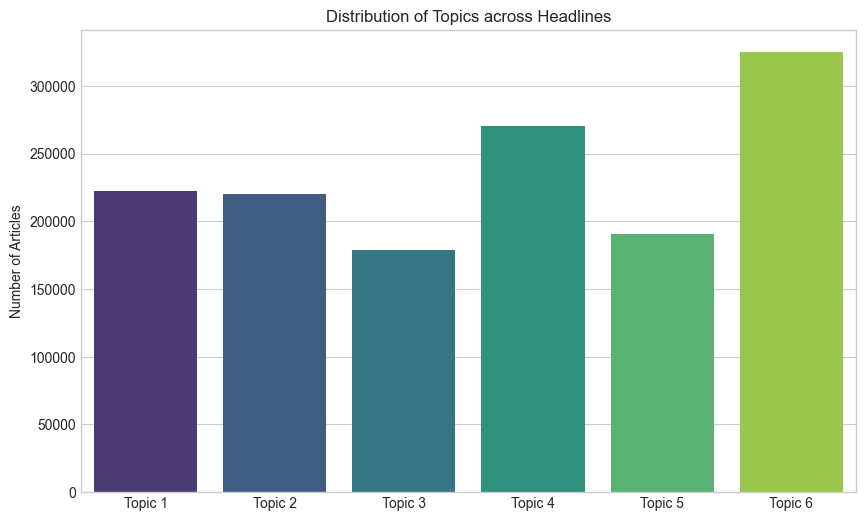

In [40]:
topic_counts = text_data['topic'].value_counts().sort_index()
topic_labels = [f"Topic {i+1}" for i in range(6)] 

plt.figure(figsize=(10, 6))
sns.barplot(x=topic_labels, y=topic_counts.values, palette='viridis')
plt.title('Distribution of Topics across Headlines')
plt.ylabel('Number of Articles')
plt.show()

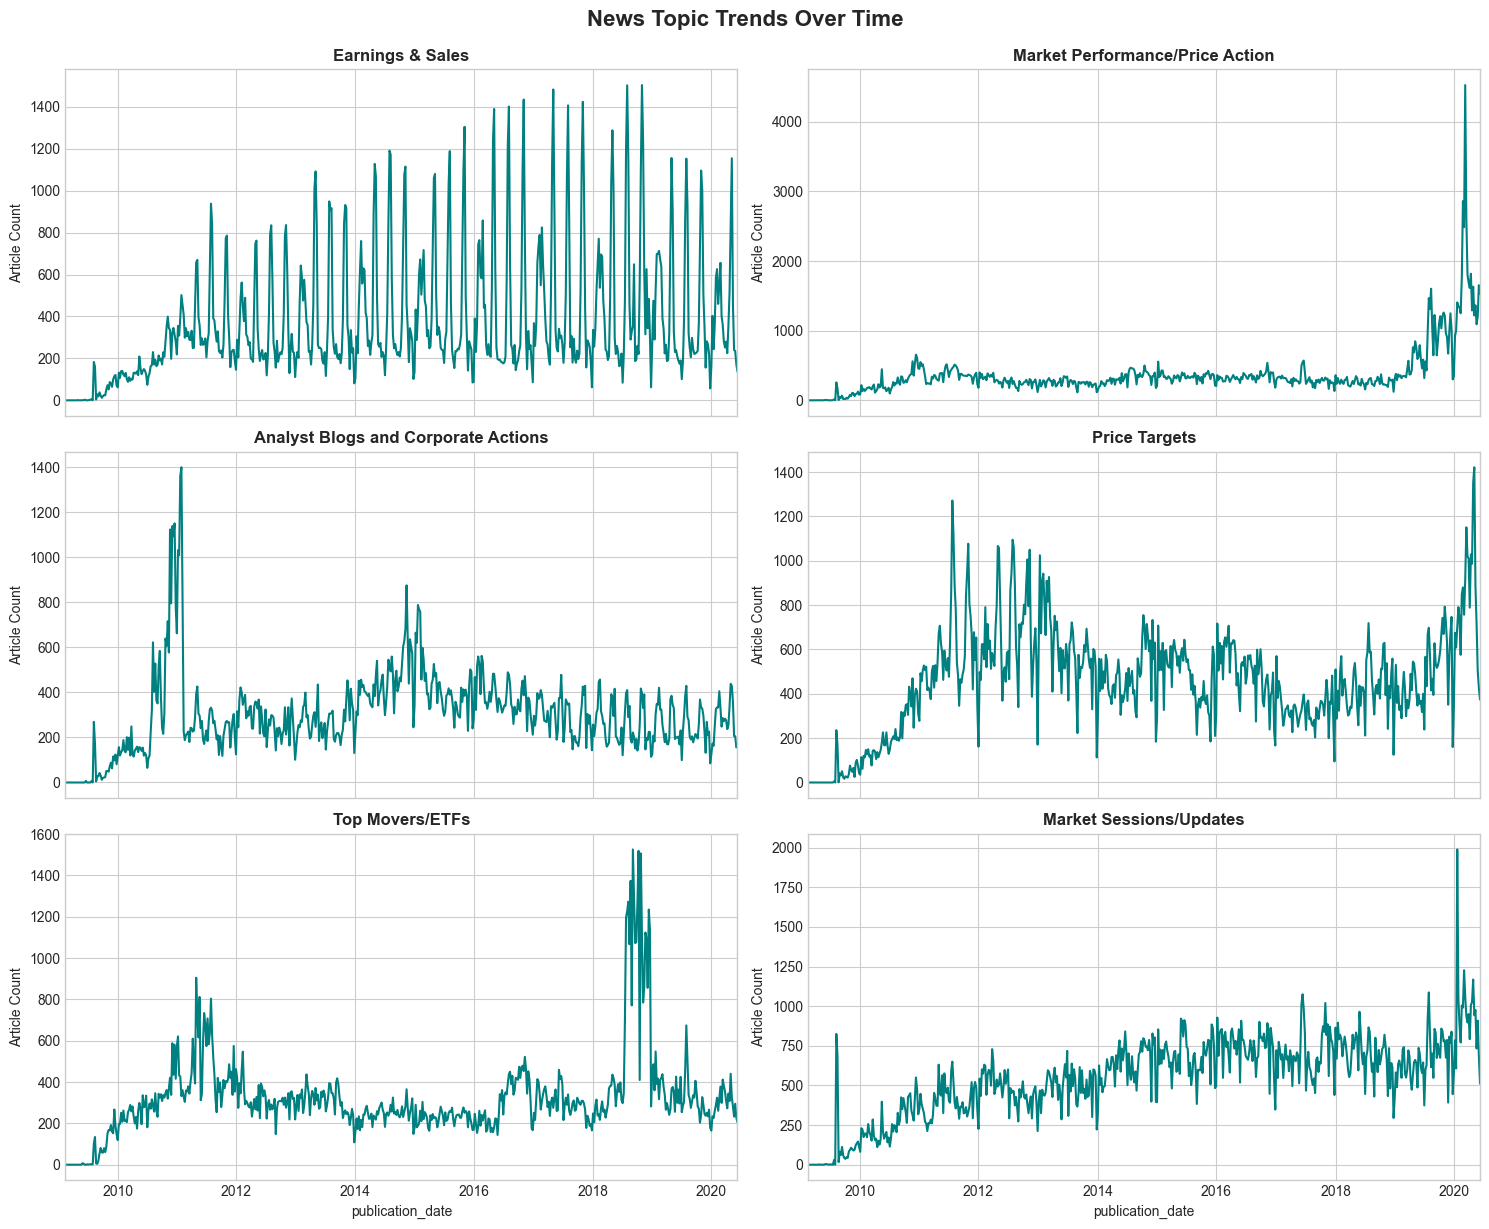

In [31]:
topic_weekly = text_data.groupby(['publication_date', 'topic']).size().unstack(fill_value=0).resample('W').sum()

topic_names = {
    0: "Earnings & Sales",
    1: "Market Performance/Price Action",
    2: "Analyst Blogs and Corporate Actions",
    3: "Price Targets",
    4: "Top Movers/ETFs",
    5: "Market Sessions/Updates"
}
topic_weekly.columns = [topic_names.get(col, f"Topic {col}") for col in topic_weekly.columns]

plt.style.use('seaborn-v0_8-whitegrid') 
axes = topic_weekly.plot(subplots=True, 
                         layout=(3, 2), 
                         figsize=(15, 12), 
                         sharex=True, 
                         color='teal', 
                         linewidth=1.5,
                         legend=False)


for i, ax in enumerate(axes.flatten()):
    ax.set_title(topic_weekly.columns[i], fontweight='bold', fontsize=12)
    ax.set_ylabel('Article Count')

plt.tight_layout()
plt.suptitle('News Topic Trends Over Time', fontsize=16, fontweight='bold', y=1.02)
plt.show()

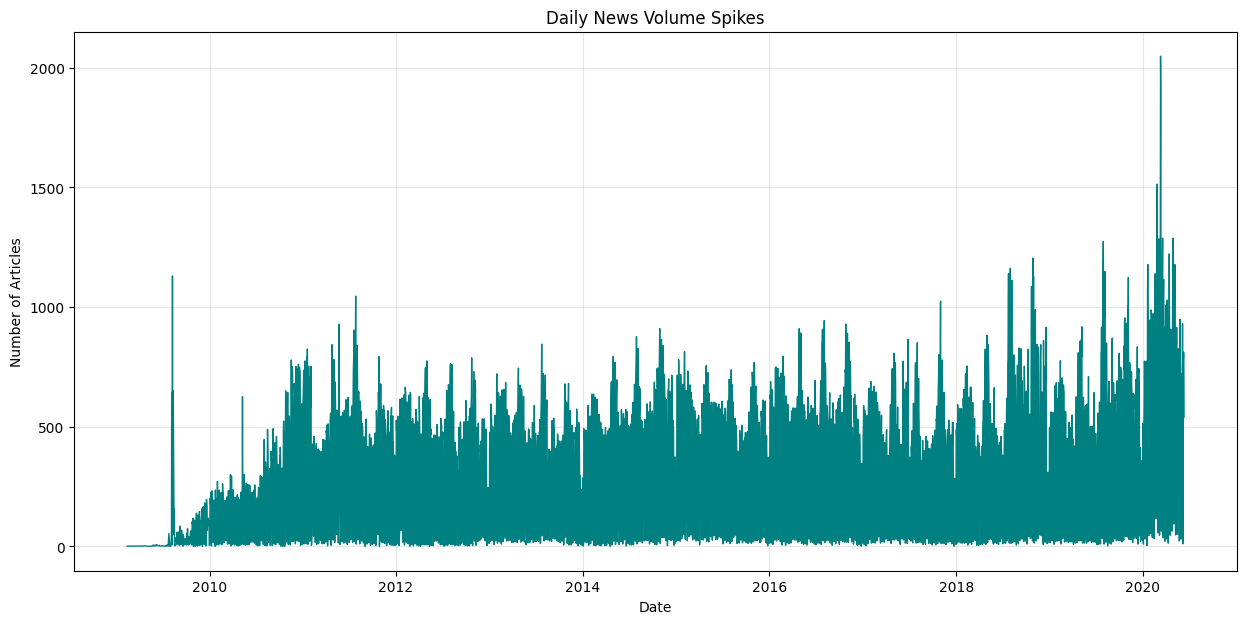

In [25]:
daily_counts = text_data.groupby(text_data['date'].dt.date).size()

plt.figure(figsize=(15, 7))
daily_counts.plot(color='teal', linewidth=1)
plt.title('Daily News Volume Spikes')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.grid(True, alpha=0.3)
plt.show()

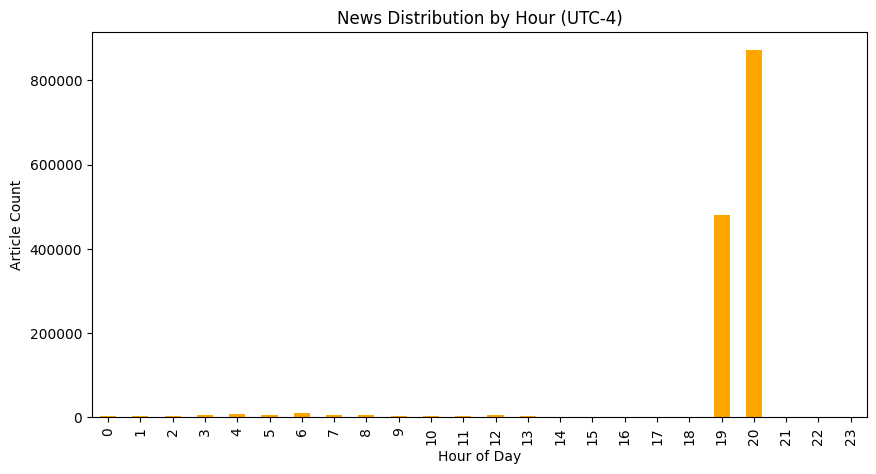

In [27]:
hourly_counts = text_data.groupby(text_data['date'].dt.hour).size()

plt.figure(figsize=(10, 5))
hourly_counts.plot(kind='bar', color='orange')
plt.title('News Distribution by Hour (UTC-4)')
plt.xlabel('Hour of Day')
plt.ylabel('Article Count')
plt.show()

### Topic and Publication Date visuals interpretation
#### 1. Distribution of Topics across Headlines
Topic 6 (Market Sessions & Updates) is the clear leader. With over 325,000 articles, this category represents the constant pulse of the market—intraday updates, pre-market movers, and CEO statements. It confirms that a large portion of financial news is focused on immediate, short-term price movement.

Topic 4 (Price target) is the second most frequent. This shows that upgrades, downgrades, and price targets are a massive driver of news volume.

Steady Core (Topics 1, 2, & 3): These topics, covering earnings reports, general price action, and dividends, each account for roughly 175,000 to 225,000 articles. They represent the fundamental layer of the news, providing the data that drives the sessions mentioned in Topic 6.

Topic 5 (ETFs & Movers) is the smallest but still significant. Its lower volume suggests it is a more specialized niche compared to the broad market updates seen in other categories.

#### 2. News Topic Trends Over Time
An examination of the News Volume Over Time reveals a structural transformation in the financial media landscape. From 2010 to 2020, there is a measurable increase in the news output, suggesting a market environment that has become increasingly saturated with information. This growth is punctuated by extreme volatility spikes that correlate with systemic shocks, most notably the 2011 U.S. Debt Ceiling crisis, the 2018 Trade War volatility, and the unprecedented surge during the 2020 Global Pandemic. These peaks illustrate that news volume acts as a high-fidelity proxy for market stress, where the frequency of reporting scales directly with the degree of economic uncertainty.


#### 3. Daily News Volume Spikes
The chart is anchored by two massive vertical spikes that represent extreme market stress:

* The 2009 Post-Recession Peak: A sudden surge as markets reacted to the fallout of the 2008 crash and the implementation of unconventional monetary policies.

* The 2020 Pandemic Surge: The most significant feature of the entire dataset. The volume nearly doubles the previous decade’s average, reaching a peak of over 2,000 articles. This reflects the total global synchronization of the COVID-19 shock, where every sector of the economy was simultaneously disrupted.

#### 4. News Distribution by Hour (UTC-4)
The most prominent feature is the massive surge in publication between 19:00 (7 PM) and 20:00 (8 PM). The volume at 20:00 exceeds 800,000 articles, which is vastly disproportionate to the rest of the day.

For the majority of the 24-hour cycle (from midnight until 18:00), news volume is negligible. This indicates that the dataset likely consists of aggregated daily reports or batch-processed releases rather than a continuous, real-time news stream.

Given the UTC-4 timezone (Eastern Time), this spike occurs shortly after the U.S. equity markets close (4 PM ET). This suggests that the headlines are largely reactive, capturing final daily tallies, closing prices, and post-market corporate filings that are summarized and blasted out in bulk once the trading day is officially over

In [28]:
def extract_domain(publisher):
    if '@' in str(publisher):
        return publisher.split('@')[-1]
    return publisher

text_data['publisher_clean'] = text_data['publisher'].apply(extract_domain)
print("\nTop Cleaned Domains/Publishers:")
print(text_data['publisher_clean'].value_counts().head(10))


Top Cleaned Domains/Publishers:
publisher_clean
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


In [41]:

publisher_topic = pd.crosstab(text_data['publisher_clean'], text_data['topic'])
print(publisher_topic.loc[text_data['publisher_clean'].value_counts().head(5).index])

topic                  0      1      2      3      4      5
publisher_clean                                            
Paul Quintaro      73951  23706  22214  45643   4506  58353
Lisa Levin         21004  36505  27850    711  50864  50045
Benzinga Newsdesk  32890  45544   8987   9303  26984  26776
Charles Gross       6432  11923  14742  21023   2445  40167
Monica Gerson      15795   6617  23453   5362  25282   5871


### Publisher Analysis
The data exhibits a significant power law distribution, where the top three publishers - `Paul Quintaro`, `Lisa Levin`, and the `Benzinga Newsdesk` collectively account for over 565,000 articles. The presence of individual names at the summit of this list suggests either highly prolific specialized contributors or, more likely, a systematic attribution of automated news feeds and high-frequency market updates to key editorial profiles.

#### cross-tabulation between the primary publishers and their respective thematic specializations
* Paul Quintaro: Quintaro exhibits the highest volume across nearly all categories, with a primary concentration in Earnings & Sales (73,951) and Market Sessions/Updates (58,353). This profile appears to be the backbone of the newsroom, handling the fundamental corporate data and the daily pulse of the market.

* Lisa Levin: shows a significant leaning toward Top Movers/ETFs (50,864) and Market Sessions (50,045). Interestingly, Lisa has a negligible presence in Price Targets (Topic 3), suggesting a focus on real-time market flow and volatility rather than predictive analyst ratings.

* Charles Gross: heavily skewed toward Market Sessions/Updates (40,167), which accounts for nearly half of his total output. This suggests a role dedicated to the high-frequency, minute-by-minute reporting required during active trading hours.

* Benzinga Newsdesk: The institutional desk maintains a balanced distribution but peaks in Market Performance/Price Action (45,544). This indicates that broad market summaries and overall performance metrics are centralized at the desk level rather than attributed to individual personalities.

In [42]:
output_path = '../../data/processed/analysed_text.csv'
text_data.to_csv(output_path, index=False, encoding='utf-8')